# 第2章 GPU 体系结构（上）：编程模型与 wavefront 执行

## 本章导读

同一个 kernel 启动了许多线程，为什么它们不会都写到同一个位置？我们从一张工作单开始，
先看任务怎样分组，再手算线程下标，最后用 HIP 验证尾部与条件分支。
本章沿用[第 1 章](../chapter1/chapter1.ipynb)准备的环境，可以从空白内核独立运行。
[对应正文](../../../docs/part0-intro/chapter2/index.md)提供更完整的线程分组图解。


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu

cfg = gpu.settings()
torch.manual_seed(cfg["seed"])
%load_ext hello_gpu
cfg


## 2.1 GPU 计算的基本流程

CPU 准备输入并发起计算，GPU 执行许多份同样的工作单，CPU 在使用结果前确认计算完成。
Kernel 就是工作单上的函数；Thread 是带着自己编号执行这个函数的一份工作。
对于数组加法，每个有效线程都要完成“取两个数、相加、写回”，不是只负责其中一个动作。


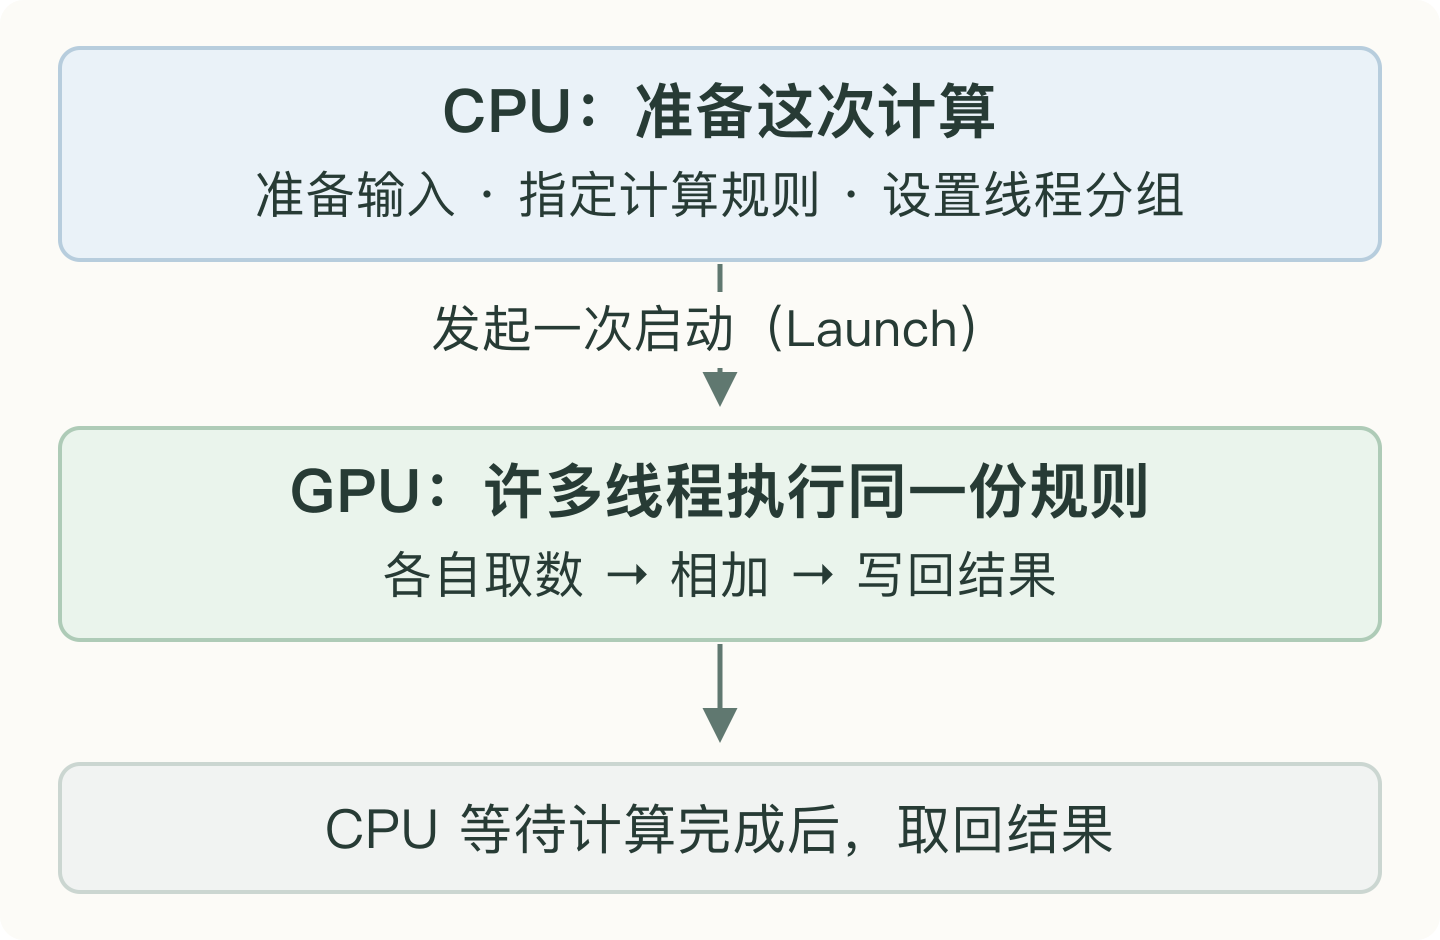

*发起任务、执行计算和使用结果分别处于流程中的不同位置。*


In [ ]:
a = [1, 2, 3, 4]
b = [10, 20, 30, 40]
work_items = [{"i": i, "read": (a[i], b[i]), "write": a[i] + b[i]}
              for i in range(len(a))]
work_items


**观察**：工作单相同，每份工作的 `i` 和输入不同。这只是 CPU 上的数据分工模型，
尚未模拟 GPU 的执行顺序；线程编号也不承诺谁先执行。


## 2.2 线程的组织与执行

一次启动的全部线程块构成 Grid；一个 Block 包含一组线程，组内可以在需要时共享数据和同步。
Block 内部又按 kernel 的执行配置组成 wavefront，lane 表示线程在这个执行小组里的位置。
我们指定 block 大小，并不需要逐个安排 wavefront 的执行时刻。

| 名称 | 本章先回答的问题 |
| --- | --- |
| Grid | 这次提交了哪些 block？ |
| Block | 哪些线程属于同一个协作组？ |
| Thread | 谁在执行这一份 kernel？ |
| Wavefront / lane | 共同执行指令的是哪组线程，各自处于什么位置？ |

下面只用每块四个线程做编号练习。四是方便手算的 block 大小，不是设备的 wavefront 大小。


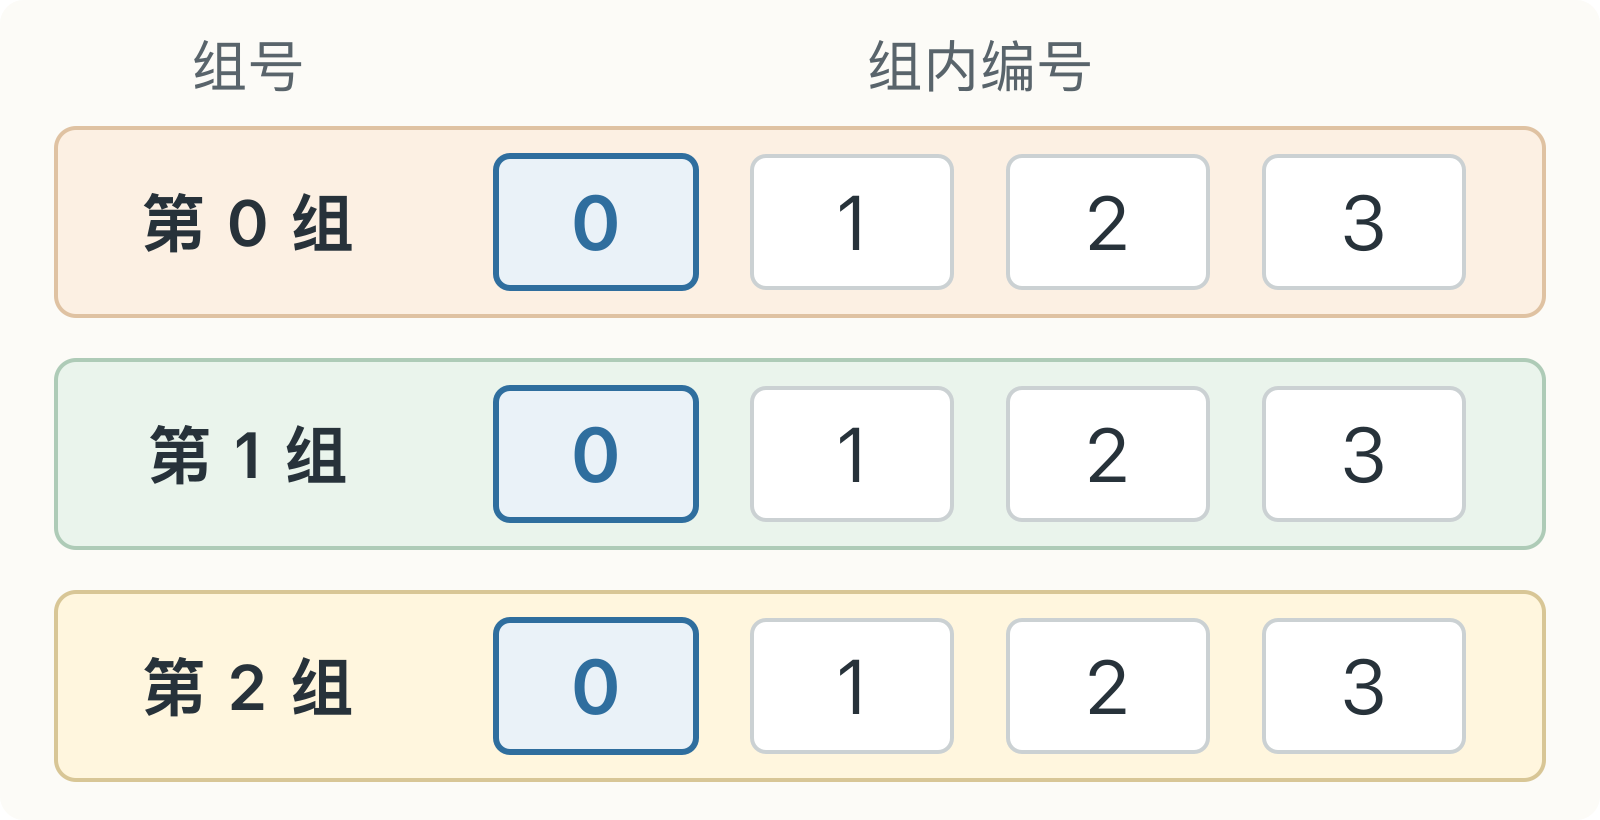

*每块都有自己的 0 号线程，因此要用块号与块内编号一起识别线程。*


In [ ]:
import pandas as pd

toy_n, toy_block = 10, 4
toy_grid = (toy_n + toy_block - 1) // toy_block
groups = [{"block": group, "thread": lane}
          for group in range(toy_grid) for lane in range(toy_block)]
pd.DataFrame(groups)


**观察**：12 份线程工作覆盖 10 个元素；多出来的两份工作仍被启动，但必须跳过数组读写。
下一节把“线程是谁”变成“它处理哪里”。


## 2.3 线程编号与数据索引

每块负责一段连续位置时，数组下标是 `块号 × 每块线程数 + 块内线程号`。
这个下标由源码里的公式决定，不是 Tensor 自动塞给每个线程的。改变公式会改变数据分工，
因此还要检查是否遗漏、重复写入或越界。


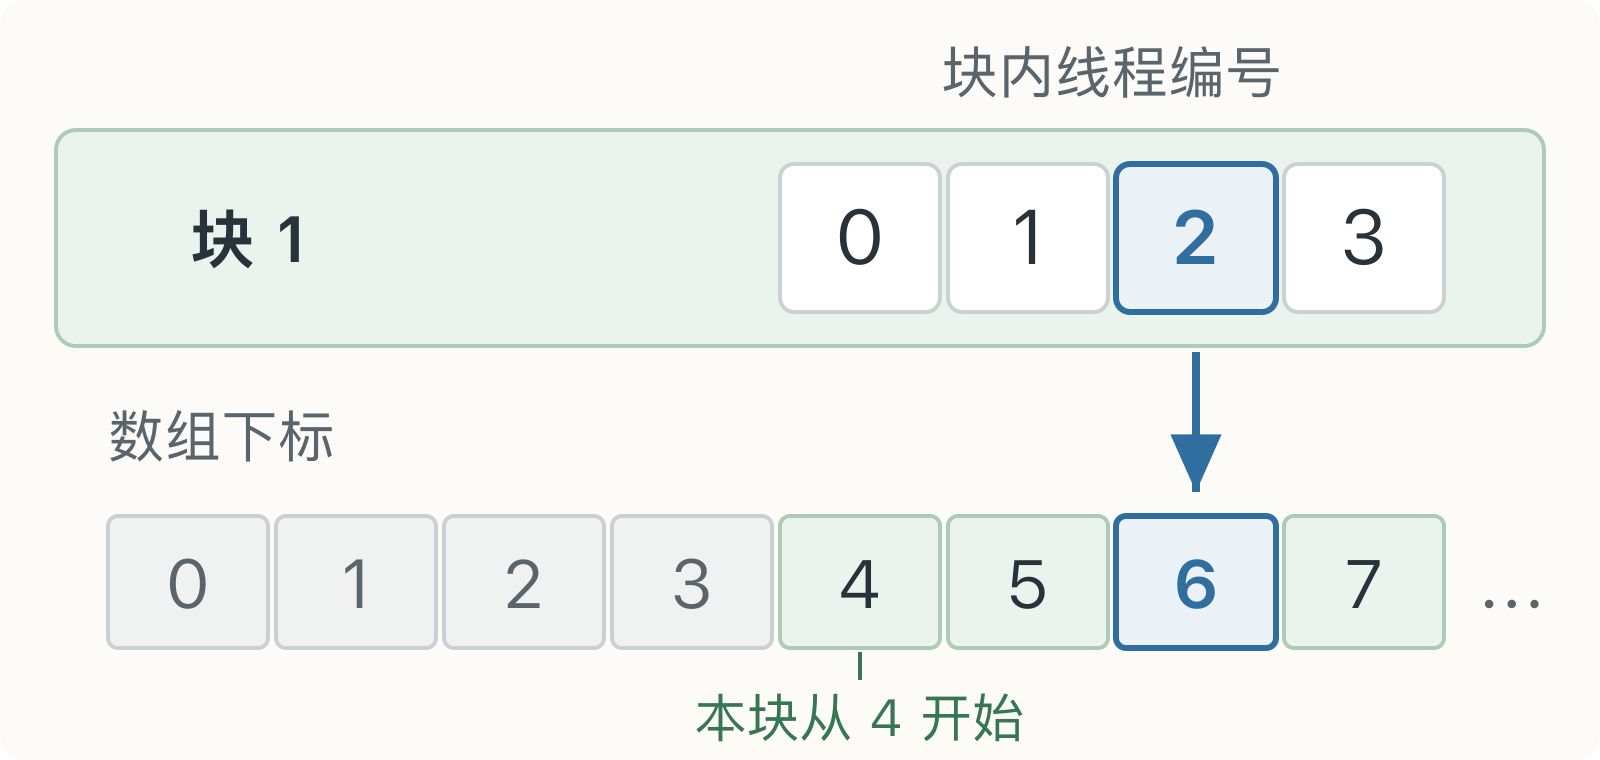

*先找到 block 起点，再加上块内偏移，得到数组下标。*


In [ ]:
mapping = pd.DataFrame(groups)
mapping["i"] = mapping["block"] * toy_block + mapping["thread"]
mapping["valid"] = mapping["i"] < toy_n
assert mapping.loc[mapping["valid"], "i"].tolist() == list(range(toy_n))
mapping


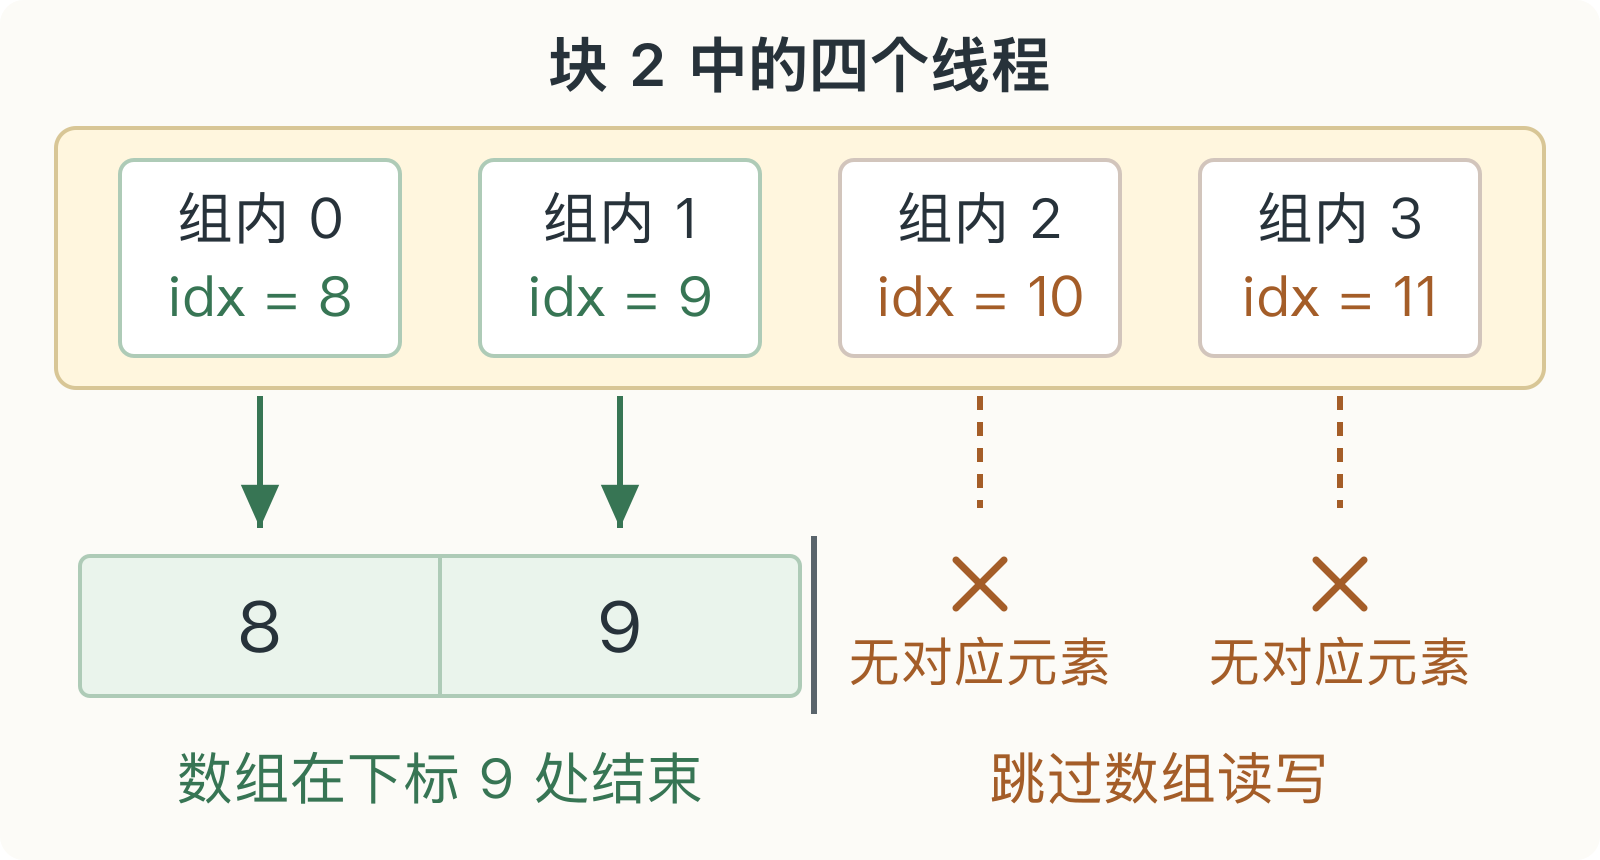

*最后一块中超出数组长度的位置，只跳过读写，不改变原有线程编号。*


现在写 HIP。`blockIdx.x`、`blockDim.x` 和 `threadIdx.x` 分别提供块号、块大小和块内线程号。
`if (i < n)` 将刚才表格中的 `valid` 条件落实到每次读写之前。


In [ ]:
%%hip indexed_add --preset binary_f32

__global__ void kernel(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
n, block = cfg["n"], cfg["block"]
checked = []
for length in (0, 1, block - 1, block + 3, n + 3):
    a = torch.randn(length, device="cuda", dtype=torch.float32)
    b = torch.randn_like(a)
    c = indexed_add(a, b, block=block)
    torch.testing.assert_close(c, a + b, rtol=0, atol=0)
    checked.append({"n": length, "blocks": (length + block - 1) // block, "correct": True})
pd.DataFrame(checked)


**观察**：边界判断让非整除长度也有完整结果。空输入由调用层直接返回空 Tensor，
不需要启动一个“没有有效元素”的 kernel。读到 `correct=True` 只说明这些输入通过检查。

### 分支条件怎样对应到位置

把任务改成：偶数位置做加法，奇数位置做减法。它仍然是一份 kernel，只是不同线程根据自己的
`i` 选择分支。这里先验证映射，不从分支数量直接推断快慢。


In [ ]:
%%hip alternating --preset binary_f32
__global__ void kernel(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    if (i % 2 == 0) c[i] = a[i] + b[i];
    else c[i] = a[i] - b[i];
}


In [ ]:
length = block + 3
a = torch.randn(length, device="cuda")
b = torch.randn_like(a)
indices = torch.arange(length, device="cuda")
expected = torch.where(indices % 2 == 0, a + b, a - b)
actual = alternating(a, b, block=block)
torch.testing.assert_close(actual, expected, rtol=0, atol=0)
preview = min(8, length)
pd.DataFrame({"i": range(preview),
              "branch": ["add" if i % 2 == 0 else "subtract" for i in range(preview)],
              "result": actual[:preview].cpu().tolist()})


同一 wavefront 中参与某条指令的线程可以是其中一部分。条件掩码保证每个位置遵循自己的规则；
具体执行了哪些指令、分支是否被编译器改写，要看编译结果与测量证据。
不能仅凭源码里有一个 `if` 就认定它是瓶颈。


## 2.4 线程分组与硬件执行单元

Block 与 wavefront 是软件工作分组，SIMD、CU 等是承接工作的硬件组织。
启动更多线程不等于芯片上增加了更多执行单元；硬件在资源允许时让部分工作驻留并推进。
RDNA 还使用 WGP 组织相关资源，具体放置与执行模式需要结合目标和编译产物理解。


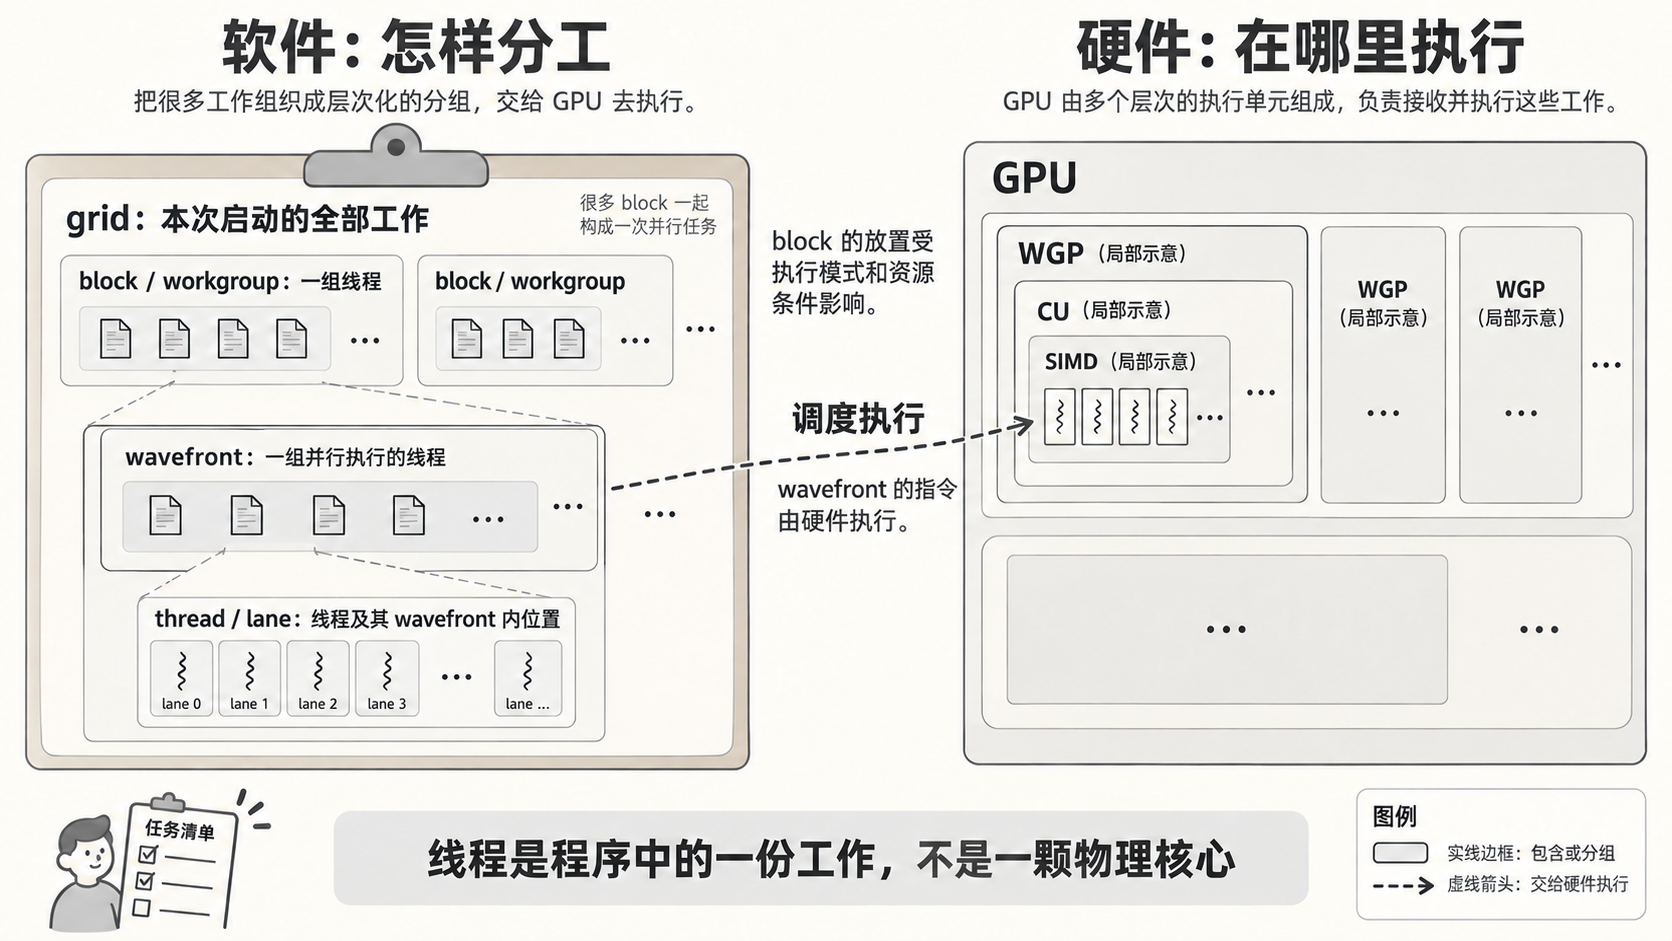

*软件描述有哪些工作，硬件决定何时执行已就绪的指令；图不是一一独占关系。*


In [ ]:
context = gpu.environment()
pd.DataFrame([{"block": size, "grid": (n + size - 1) // size,
               "logical_threads": ((n + size - 1) // size) * size}
              for size in (64, 128, 256)])


**观察**：表中能算出逻辑工作量，却没有“同时执行线程数”这一列。
并发还依赖寄存器、共享存储和调度条件。这正是[第 3 章](../chapter3/chapter3.ipynb)接下来要追踪的数据与资源。

## 自我检验

1. 不运行代码，先算 `N=1000, block=256` 时需要几块，尾块有多少有效线程，再用 Python 核对。
2. 把 `alternating` 改成每连续四个位置共用一个分支。先写 PyTorch 参考，再修改 HIP 并检查非整除长度。
3. 为什么“线程 35”和“lane 3”可能描述同一份工作？回答时明确假设的 wavefront 大小，不把它当作所有设备的常量。
4. 增大 block 后 grid 变小，能否只凭这个变化宣布更快？还缺哪些测量？

## 本章小结

线程编号给出身份，索引公式决定数据分工，边界判断保护数组。
我们用相同的分工模型连起了手算表、HIP kernel 与 PyTorch 参考。
下一章[数据存储与访问](../chapter3/chapter3.ipynb)继续追踪每个线程读来的值去了哪里。
